# **Import Data + Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import umap


In [3]:
clustering_data = pd.read_csv('/content/drive/MyDrive/Capstone/cleaned_cluster_data.csv')
morbidity_outcomes = pd.read_csv('/content/drive/MyDrive/Capstone/cleaned_morbidity_outcome_data.csv')

print(f'Shape of Cluster Data:', clustering_data.shape)
display(clustering_data.head())
print(f'Shape of Morbidity Data:', morbidity_outcomes.shape)
display(morbidity_outcomes.head())

Shape of Cluster Data: (3638436, 38)


,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,tbo_rec,precare,mracehisp_1.0,mracehisp_2.0,mracehisp_3.0,mracehisp_4.0,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown
0,30,1.0,0.0,0.0,0.0,30.0,66.0,20.799999,4.0,38.0,...,2.0,3.0,0,1,0,0,0,0,0,0
1,28,0.0,0.0,0.0,0.0,36.0,67.0,20.400000,40.0,38.0,...,1.0,3.0,0,0,0,0,0,1,0,0
2,41,6.0,0.0,2.0,2.0,84.0,67.0,22.700001,28.0,37.0,...,8.0,2.0,1,0,0,0,0,0,0,0
3,29,2.0,0.0,0.0,0.0,49.0,61.0,26.400000,28.0,38.0,...,3.0,3.0,1,0,0,0,0,0,0,0
4,28,1.0,0.0,2.0,0.0,17.0,64.0,21.500000,31.0,39.0,...,4.0,2.0,1,0,0,0,0,0,0,0


Shape of Morbidity Data: (3638436, 5)


,mm_mtr,mm_plac,mm_rupt,mm_uhyst,mm_aicu
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


/tmp/ipykernel_5084/3884383958.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


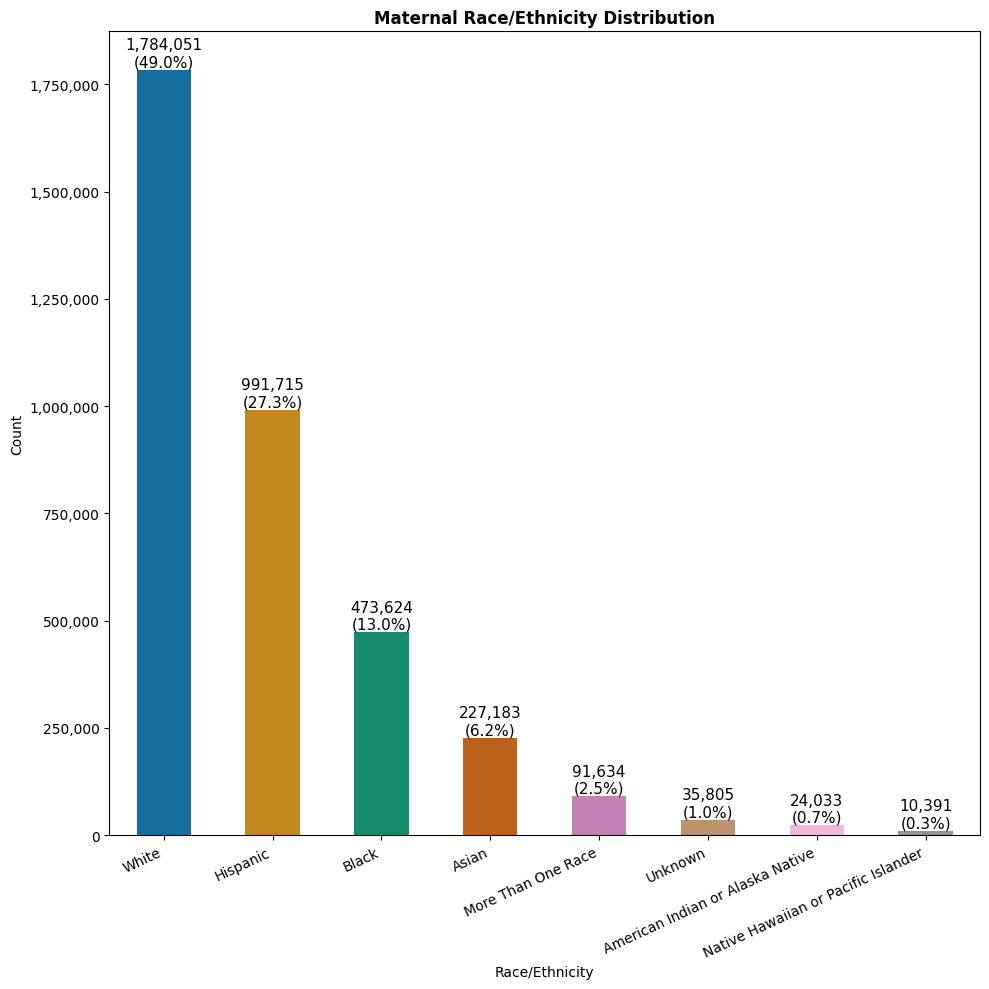

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

racial_map = {
    'mracehisp_1.0': 'White',
    'mracehisp_2.0': 'Black',
    'mracehisp_3.0': 'American Indian or Alaska Native',
    'mracehisp_4.0': 'Asian',
    'mracehisp_5.0': 'Native Hawaiian or Pacific Islander',
    'mracehisp_6.0': 'More Than One Race',
    'mracehisp_7.0': 'Hispanic',
    'mracehisp_Unknown': 'Unknown'
}

race_counts = clustering_data[list(racial_map.keys())].sum().rename(index=racial_map)
race_counts = race_counts.sort_values(ascending=False)

race_pct = (race_counts / len(clustering_data)) * 100

plt.figure(figsize=(10,10))

ax = sns.barplot(
    x=race_counts.index,
    y=race_counts.values,
    palette='colorblind',
    width = 0.5
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

for i, (count, pct) in enumerate(zip(race_counts.values, race_pct.values)):
    ax.text(
        i,
        count,
        f'{int(count):,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.title('Maternal Race/Ethnicity Distribution', fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Race/Ethnicity')
plt.xticks(rotation=25, ha='right')

plt.tight_layout()
plt.show()

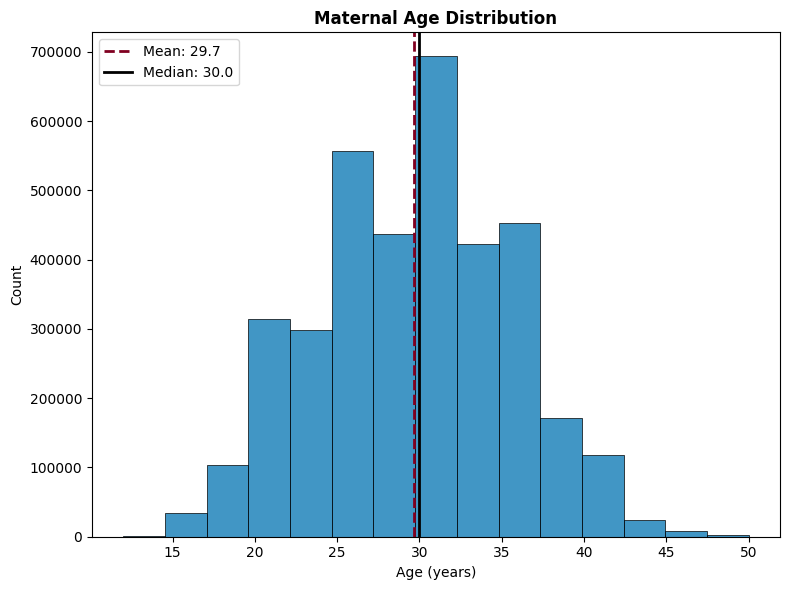

In [5]:
# Age Distrbution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

ax = sns.histplot(
    data=clustering_data,
    x='mager',              # <-- replace if your column name is different
    bins=15,
    color=sns.color_palette('colorblind')[0],
    edgecolor='black',
    linewidth=0.5
)

mean_age = clustering_data['mager'].mean()
median_age = clustering_data['mager'].median()

plt.axvline(mean_age, color = '#800020', linestyle='--', label=f'Mean: {mean_age:.1f}', linewidth = 2)
plt.axvline(median_age, color = 'black', linestyle='-', label=f'Median: {median_age:.1f}', linewidth = 2)

plt.legend(loc = 'upper left')

plt.title('Maternal Age Distribution', fontweight='bold')
plt.xlabel('Age (years)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# **PCA**

## *Scale Data + Set PCA model*

In [6]:
# Scale the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_data)

In [7]:
# PCA
pca = PCA(n_components = 0.90, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

print('Number of PCA components:', pca.n_components_)
print('Explained Variance:', np.sum(pca.explained_variance_ratio_) * 100, '%')

Number of PCA components: 28
Explained Variance: 92.01779388589084 %


## *Determine the Best K using Inertia + Silhouette Scores*
----
sample size of 250,000

In [8]:
# Determine Best K (Inertia + Silhouette)
sample_gen = np.random.default_rng(42)
samplesize = min(250000, len(X_pca))
sample_index = sample_gen.choice(np.arange(len(X_pca)), size = samplesize, replace = False)
X_pca_sample = X_pca[sample_index]

k_values = range(2, 11)
inertia_values = []
silhouette_values = []

for k in k_values:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 'auto')
  cluster_labels = kmeans.fit_predict(X_pca_sample)
  inertia_values.append(kmeans.inertia_)
  silhouette = silhouette_score(
      X_pca_sample,
      cluster_labels,
      sample_size = 25000,
      random_state = 42
  )
  silhouette_values.append(silhouette)
  print(f'K = {k} -- Inertia = {kmeans.inertia_:.3f} -- Silhouette = {silhouette_values[-1]:.4f}')

K = 2 -- Inertia = 8007904.430 -- Silhouette = 0.2008
K = 3 -- Inertia = 7761410.208 -- Silhouette = 0.2074
K = 4 -- Inertia = 7504639.459 -- Silhouette = 0.2079
K = 5 -- Inertia = 6964149.975 -- Silhouette = 0.1889
K = 6 -- Inertia = 6627310.725 -- Silhouette = 0.1142
K = 7 -- Inertia = 6524437.617 -- Silhouette = 0.1637
K = 8 -- Inertia = 6273615.951 -- Silhouette = 0.1247
K = 9 -- Inertia = 6034647.646 -- Silhouette = 0.1386
K = 10 -- Inertia = 5813062.229 -- Silhouette = 0.1620


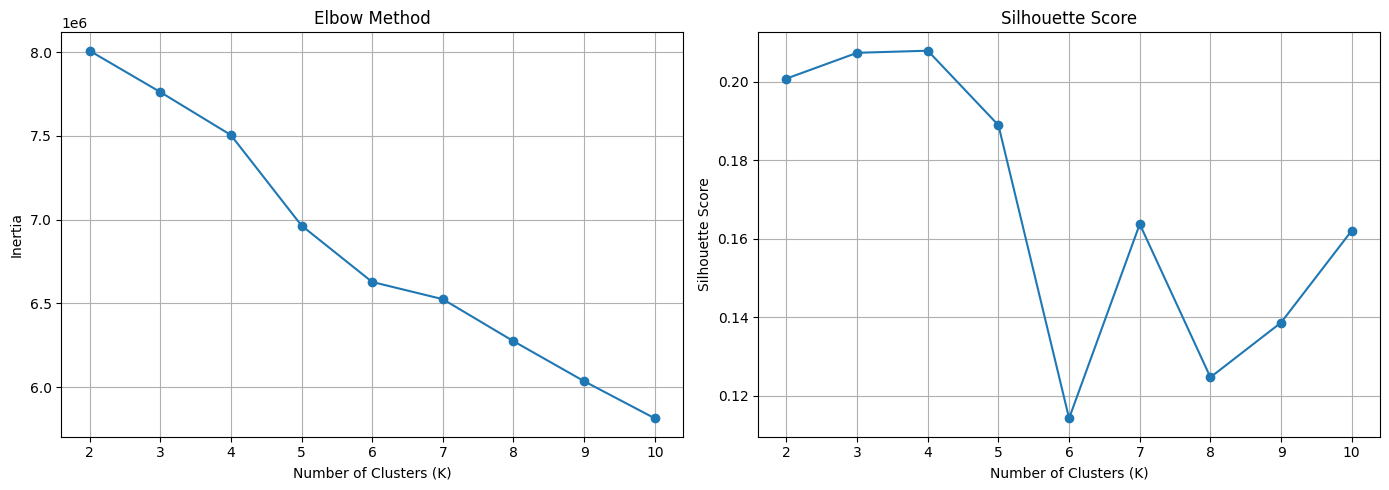

In [9]:
# Plot Inertia + Silhouette
fig, ax = plt.subplots(1, 2, figsize = (14, 5))
ax[0].plot(list(k_values), inertia_values, marker = 'o')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia')
ax[0].set_title('Elbow Method')
ax[0].grid(True)

ax[1].plot(list(k_values), silhouette_values, marker = 'o')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_title('Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Export K Selection Results Table
k_select_results = pd.DataFrame({
    'K': k_values,
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_values
})

display(k_select_results)

# Export Results
#k_select_results.to_csv('/content/drive/MyDrive/Capstone/k_select_results.csv', index = False)

,K,Inertia,Silhouette Score
0,2,8.007904e+06,0.200793
1,3,7.761410e+06,0.207361
2,4,7.504639e+06,0.207891
3,5,6.964150e+06,0.188905
4,6,6.627311e+06,0.114223
5,7,6.524438e+06,0.163706
6,8,6.273616e+06,0.124683
7,9,6.034648e+06,0.138626
8,10,5.813062e+06,0.162044


## *Run KMeans on Full Dataset*

In [11]:
# Use Final KMean on Full Data
fulldata_kmeans = KMeans(n_clusters = 4, random_state = 42, n_init = 'auto')
fulldata_clusters = fulldata_kmeans.fit_predict(X_pca)

official_clustered_data = clustering_data.copy()
official_clustered_data['cluster'] = fulldata_clusters

cluster_count = official_clustered_data['cluster'].value_counts().sort_index()
cluster_count_percent = official_clustered_data['cluster'].value_counts(normalize = True).sort_index() * 100

print('Cluster Sizes:')
cluster_proportion = pd.concat([cluster_count, cluster_count_percent], axis = 1)
cluster_proportion.columns = ['Count', 'Percent']
display(cluster_proportion)

Cluster Sizes:


,Count,Percent
cluster,,
0,595862,16.376872
1,1193373,32.799065
2,1566805,43.062596
3,282396,7.761467


In [12]:
# Final Silhouette Score
finalsamplesize = min(100000, len(X_pca))
finalsampleindex = sample_gen.choice(len(X_pca), size = finalsamplesize, replace=False)

final_silhouette = silhouette_score(
    X_pca[finalsampleindex],
    official_clustered_data["cluster"].iloc[finalsampleindex]
)

print(f"Final silhouette score: {final_silhouette:.4f}")

Final silhouette score: 0.0909


## *Cluster Profiles*

In [13]:
# Cluster Profiles
raw_cluster_profile = official_clustered_data.groupby('cluster').mean()
display(raw_cluster_profile.round(2))

# Export to CSV
#raw_cluster_profile.to_csv('/content/drive/MyDrive/Capstone/raw_cluster_profile.csv', index = False)

,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,tbo_rec,precare,mracehisp_1.0,mracehisp_2.0,mracehisp_3.0,mracehisp_4.0,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown
cluster,,,,,,,,,,,,,,,,,,,,,
0,33.07,3.14,0.07,1.22,0.62,52.99,63.88,31.83,26.49,37.96,...,5.23,3.21,0.44,0.22,0.01,0.03,0.01,0.03,0.24,0.01
1,27.12,0.71,0.00,0.25,0.14,45.33,63.20,30.64,28.16,38.54,...,1.97,3.20,0.01,0.25,0.01,0.02,0.00,0.05,0.64,0.02
2,30.00,0.67,0.00,0.30,0.12,38.10,64.74,27.61,32.15,38.78,...,1.97,2.75,0.88,0.01,0.00,0.10,0.00,0.01,0.00,0.00
3,31.43,1.00,0.01,0.46,0.25,48.90,63.62,32.37,25.42,38.17,...,2.47,2.93,0.44,0.10,0.01,0.13,0.00,0.02,0.29,0.01


In [14]:
# Z-Score Cluster Profiles
z_cluster_profile = raw_cluster_profile.apply(
    lambda col: (col - col.mean()) / col.std(ddof = 0),
    axis = 0
)

display(z_cluster_profile.round(2))

# Export Z-Score Cluster Profile
#z_cluster_profile.to_csv('/content/drive/MyDrive/Capstone/z_cluster_profile.csv', index = False)

,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,tbo_rec,precare,mracehisp_1.0,mracehisp_2.0,mracehisp_3.0,mracehisp_4.0,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.22,1.72,1.73,1.70,1.68,1.22,0.04,0.66,-0.61,-1.27,...,1.71,0.97,-0.00,0.83,0.98,-0.82,1.10,0.28,-0.23,0.21
1,-1.50,-0.65,-0.62,-0.78,-0.72,-0.18,-1.17,0.01,0.04,0.56,...,-0.69,0.91,-1.41,1.06,0.59,-1.11,0.51,1.38,1.53,1.38
2,-0.18,-0.69,-0.67,-0.66,-0.80,-1.50,1.56,-1.63,1.60,1.31,...,-0.69,-1.41,1.42,-1.39,-1.64,0.62,-1.59,-1.40,-1.27,-1.43
3,0.47,-0.37,-0.43,-0.25,-0.16,0.47,-0.43,0.95,-1.03,-0.60,...,-0.33,-0.47,-0.00,-0.50,0.07,1.31,-0.03,-0.26,-0.03,-0.16


Instead of analyzing raw values, z-scores demonstrates the true relative differences of how each cluster differs.

In [15]:
label_map = {
    'mager': 'Age',
    'meduc': 'Eeducation Level',
    'priorlive': 'Prior Births',
    'priordead': 'Prior Deaths',
    'priorterm': 'Prior Term',
    'rf_cesarn': 'Prior C-Section',
    'lbo_rec': 'Live Birth Order',
    'tbo_rec': 'Total Birth Order',
    'illb_r': 'Interval Last Preg',
    'm_ht_in': 'Height (in)',
    'bmi': 'BMI',
    'wtgain': 'Weight Gain',
    'combgest': 'Combined Gest',
    'previs': '# Prenatal Visits',
    'precare': 'PreCare Initation',
    'rf_pdiab': 'Pre-preg. Diabetes',
    'rf_gdiab': 'Gest. Diabetes',
    'rf_phype': 'Pre-preg. HTN',
    'rf_ghype': 'Gest. HTN',
    'rf_ehype': 'Eclampsia',
    'rf_ppterm': 'Prev. Preterm',
    'ip_gon': 'Gonorrhea',
    'ip_syph': 'Syphilis',
    'ip_chlam': 'Chlamydia',
    'ip_hepb': 'Hep. B',
    'ip_hepc': 'Hep. C',
    'cig_0': 'Smoking BP',
    'cig_1': 'Smoking T1',
    'cig_2': 'Smoking T2',
    'cig_3': 'Smoking T3',
    'ip_gon': 'Gonorrhea',
    'ip_syph': 'Syphilis',
    'ip_hepb': 'Hepatitis B',
    'ip_hepc': 'Hepatitis C',
    'mracehisp_1.0': 'White',
    'mracehisp_2.0': 'Black',
    'mracehisp_3.0': 'AIAN',
    'mracehisp_4.0': 'Asian',
    'mracehisp_5.0': 'NHOPI',
    'mracehisp_6.0': 'MTOR',
    'mracehisp_7.0': 'Hispanic',
    'mracehisp_Unknown': 'Unknown'
}

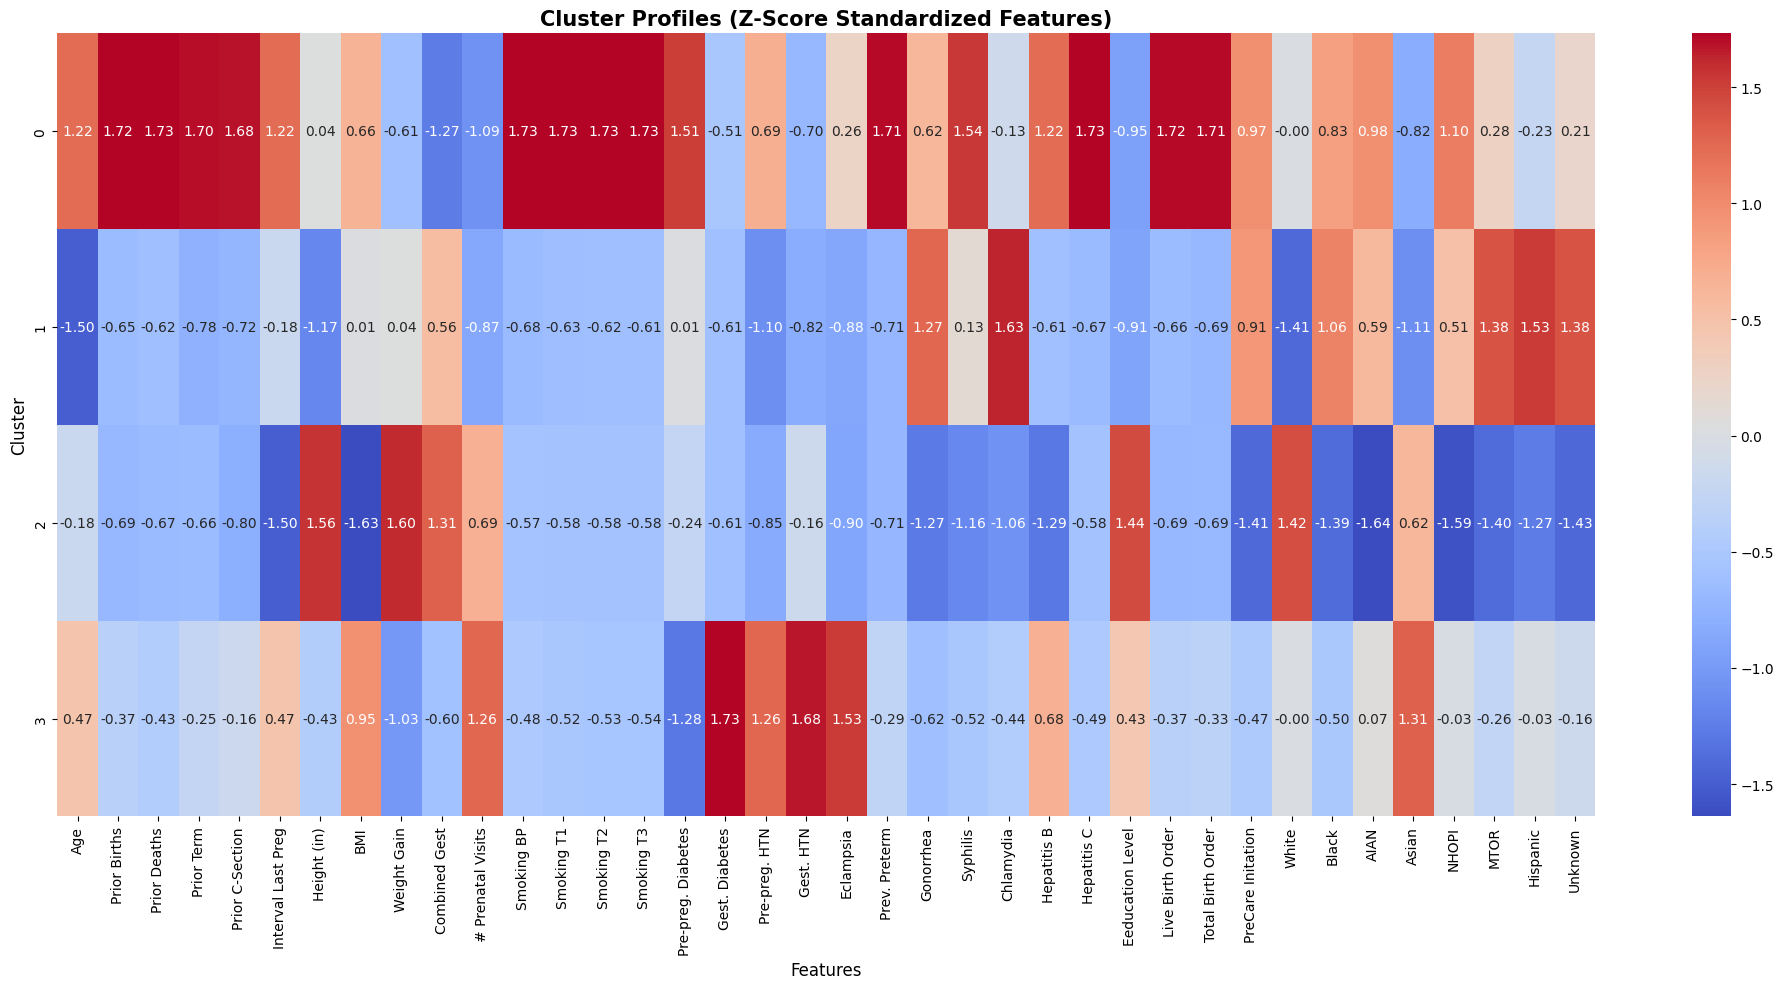

In [16]:
# Cluster Profile Heatmap
heatmap_df = z_cluster_profile.copy()
heatmap_df = heatmap_df.rename(columns = label_map)

plt.figure(figsize = (20, 10))
sns.heatmap(heatmap_df, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.title('Cluster Profiles (Z-Score Standardized Features)', fontsize = 15, fontweight = 'bold')
plt.xlabel('Features', fontsize = 12, fontweight = 'light')
plt.ylabel('Cluster', fontsize = 12, fontweight = 'light')
plt.tight_layout()
plt.show()

### *Parallel Coordinates*

In [17]:
demographics = ['mager', 'meduc', 'mracehisp_1.0','mracehisp_2.0','mracehisp_3.0','mracehisp_4.0',
                'mracehisp_5.0','mracehisp_6.0','mracehisp_7.0', 'mracehisp_Unknown']
reproductive_history = ['priorlive','priordead','priorterm','rf_cesarn','rf_ppterm','illb_r', 'tbo_rec', 'lbo_rec']
anthropometrics = ['m_ht_in','bmi','wtgain']
pregnancy_course = ['combgest','previs','precare']
clinical_risks = ['rf_pdiab','rf_gdiab','rf_phype','rf_ghype','rf_ehype']
infections = ['ip_gon','ip_syph','ip_chlam','ip_hepb','ip_hepc']
behavioral = ['cig_0','cig_1','cig_2','cig_3']

In [18]:
all_features = (
    demographics +
    reproductive_history +
    anthropometrics +
    pregnancy_course +
    clinical_risks +
    infections +
    behavioral
    )

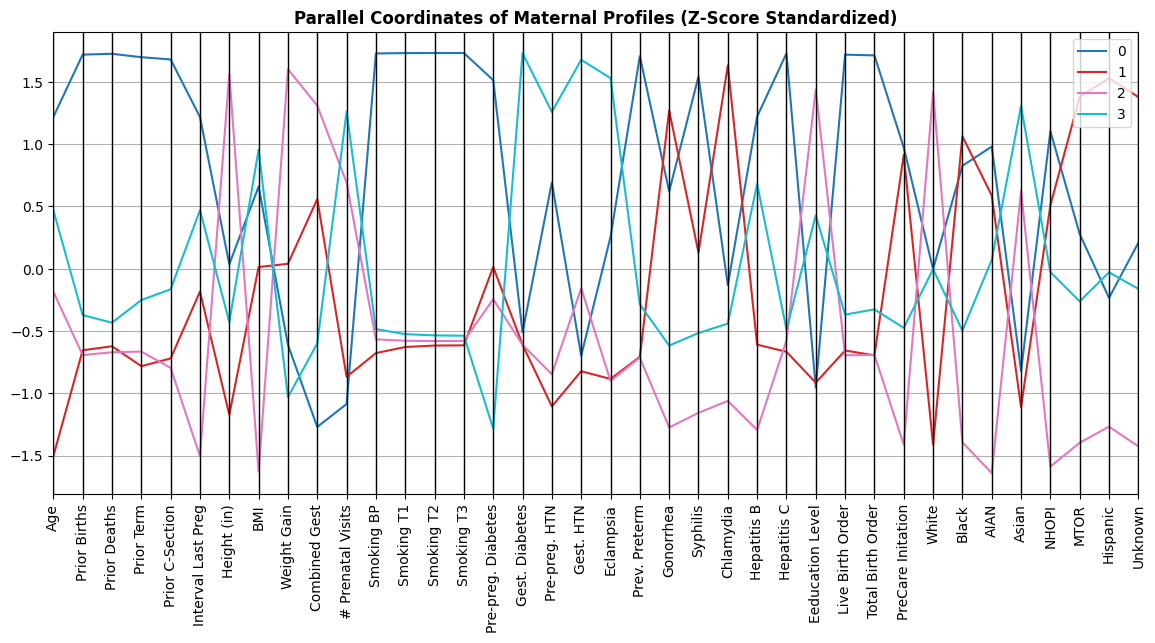

In [19]:
from pandas.plotting import parallel_coordinates

pc_df = z_cluster_profile.reset_index()
pc_df = pc_df.rename(columns = label_map)

plt.figure(figsize = (14,6))
parallel_coordinates(
    pc_df,
    'cluster',
    colormap = plt.cm.tab10,
)
plt.xticks(rotation = 90)
plt.title('Parallel Coordinates of Maternal Profiles (Z-Score Standardized)', fontweight = 'bold')
plt.show()

### Interactive Parallel Coordinates Plot

In [20]:
import plotly.express as px

pc_df = z_cluster_profile.reset_index()
pc_df = pc_df.rename(columns=label_map)

# Create numeric color mapping (0,1,2,3)
pc_df['cluster_num'] = pc_df['cluster'].astype(int)

# Define 4 distinct colors
color_scale = [
    [0.0, "#1f77b4"],   # Profile 1
    [0.33, "#ff7f0e"],  # Profile 2
    [0.66, "#2ca02c"],  # Profile 3
    [1.0, "#d62728"]    # Profile 4
]

fig = px.parallel_coordinates(
    pc_df,
    color='cluster_num',
    dimensions=[col for col in pc_df.columns if col not in ['cluster', 'cluster_num']],
    color_continuous_scale=color_scale,
)

fig.update_layout(
    title='Interactive Parallel Coordinates of Maternal Profiles',
    margin = dict(t = 100)
)

fig.show()

In [21]:
# demographic and smoking
demo_smoke_features = demographics + behavioral

# Correct subsetting
demo_smoke_df = pc_df[['cluster'] + [label_map.get(col, col) for col in demo_smoke_features]]

fig = px.parallel_coordinates(
    demo_smoke_df,
    color='cluster',
    dimensions=[col for col in demo_smoke_df.columns if col != 'cluster'],
    color_continuous_scale=color_scale,
    range_color=[0, 3]
)

fig.update_layout(
    title='Parallel Coordinates: Demographics & Behavioral Factors',
    margin = dict(t = 100)
)

fig.show()

In [22]:
# clinical risk and infection
clin_inf_features = clinical_risks + infections

# Correct subsetting
clin_inf_df = pc_df[['cluster'] + [label_map.get(col, col) for col in clin_inf_features]]

fig = px.parallel_coordinates(
    clin_inf_df,
    color='cluster',
    dimensions=[col for col in clin_inf_df.columns if col != 'cluster'],
    color_continuous_scale=color_scale,
    range_color=[0, 3]
)

fig.update_layout(
    title='Parallel Coordinates: Comorbidity and Infection Factors',
    margin = dict(t = 100)
)

fig.show()

In [23]:
# reproductive history  and course of pregnancy
repro_preg_features = reproductive_history + pregnancy_course

# Correct subsetting
repro_preg_df = pc_df[['cluster'] + [label_map.get(col, col) for col in repro_preg_features]]

fig = px.parallel_coordinates(
    repro_preg_df,
    color='cluster',
    dimensions=[col for col in repro_preg_df.columns if col != 'cluster'],
    color_continuous_scale=color_scale,
    range_color=[0, 3]
)

fig.update_layout(
    title='Parallel Coordinates: Comorbidity and Infection Factors',
    margin = dict(t = 100)
)

fig.show()

## *UMAP Visual Code*

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



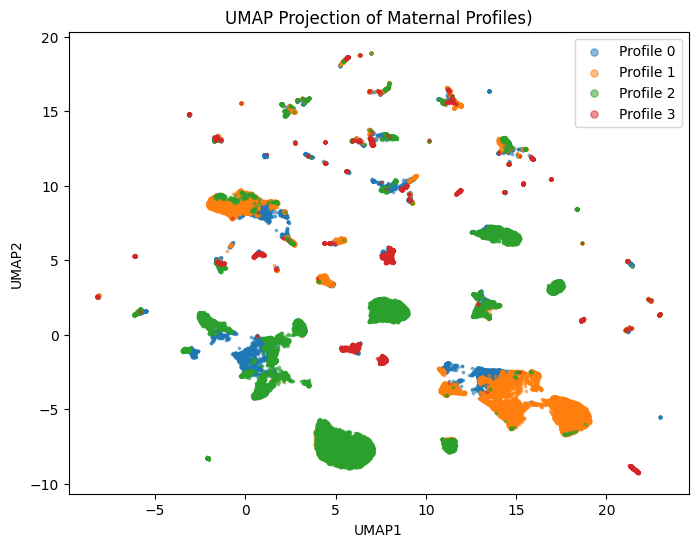

In [24]:
# Create UMAP Sample
umap_sample_size = min(100000, len(X_pca))  # safe if dataset smaller
umap_idx = np.random.choice(len(X_pca), umap_sample_size, replace=False)
X_umap_sample = X_pca[umap_idx]
cluster_umap = official_clustered_data['cluster'].iloc[umap_idx].values
unique_clusters = np.unique(cluster_umap)
cmap = plt.cm.tab10

# UMAP
umap_model = umap.UMAP(n_neighbors = 15, min_dist = 0.0, random_state = 42)
X_umap = umap_model.fit_transform(X_umap_sample)

# UMAP Visual
plt.figure(figsize=(8,6))

for i in np.unique(cluster_umap):
    mask = cluster_umap == i
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        s=3,
        alpha=0.5,
        label=f'Profile {i}'
    )

plt.title(f'UMAP Projection of Maternal Profiles)')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(markerscale = 3)
plt.show()

## *TSNE Visual Code*

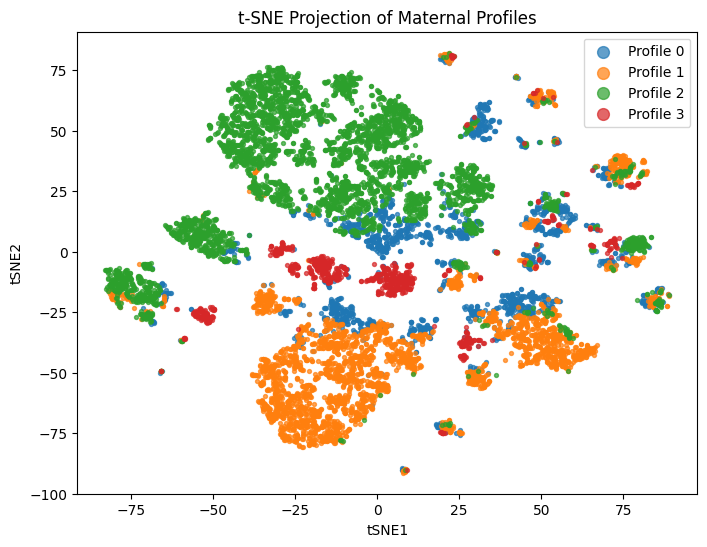

In [25]:
# Create t-SNE sample (derived from UMAP sample)
tsne_sample_size = min(10000, len(X_umap_sample))
tsne_idx = np.random.choice(len(X_umap_sample), tsne_sample_size, replace=False)
X_tsne_sample = X_umap_sample[tsne_idx]
cluster_tsne = cluster_umap[tsne_idx]

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_sample)

# t-SNE Visual
plt.figure(figsize=(8,6))

for i in np.unique(cluster_tsne):
    mask = cluster_tsne == i
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=8,
        alpha=0.7,
        label=f'Profile {i}'
    )

plt.title(f't-SNE Projection of Maternal Profiles')
plt.xlabel('tSNE1')
plt.ylabel('tSNE2')
plt.legend(markerscale = 3)
plt.show()

In [26]:
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Select features
# -----------------------------
features = [col for col in official_clustered_data.columns if col != 'cluster']

# -----------------------------
# Sample (IMPORTANT for speed)
# -----------------------------
tsne_df = official_clustered_data[features + ['cluster']].copy()
tsne_df = tsne_df.sample(n=min(8000, len(tsne_df)), random_state=42)

# -----------------------------
# Standardize (match your PCA/KMeans pipeline)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tsne_df[features])

# -----------------------------
# Run t-SNE
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=40,        # slightly higher = smoother structure
    learning_rate=200,
    n_iter=1000,
    random_state=42
)

tsne_results = tsne.fit_transform(X_scaled)

# Add results
tsne_df['tsne1'] = tsne_results[:, 0]
tsne_df['tsne2'] = tsne_results[:, 1]

# Clean cluster type
tsne_df['cluster'] = tsne_df['cluster'].astype(int)

# -----------------------------
# Interactive Plot
# -----------------------------
hover_vars = ['mager', 'tbo_rec', 'bmi', 'previs', 'rf_ghype', 'rf_gdiab', 'cig_0']

hover_labels = {
    'mager': 'Age',
    'tbo_rec': 'Total Birth Order',
    'bmi': 'BMI',
    'previs': '# Prenatal Visits',
    'rf_pdiab': 'Pre-preg. Diabetes',
    'rf_gdiab': 'Gest. Diabetes',
    'rf_phype': 'Pre-preg. HTN',
    'rf_ghype': 'Gest. HTN',
    'rf_ehype': 'Eclampsia',
    'ip_gon': 'Gonorrhea',
    'ip_syph': 'Syphilis',
    'ip_chlam': 'Chlamydia',
    'ip_hepb': 'Hep. B',
    'ip_hepc': 'Hep. C',
    'cig_0': 'Smoking BP',
    'cig_1': 'Smoking T1',
    'cig_2': 'Smoking T2',
    'cig_3': 'Smoking T3'
}

hover_vars = [col for col in hover_vars if col in tsne_df.columns]

fig = px.scatter(
    tsne_df,
    x='tsne1',
    y='tsne2',
    color='cluster',
    color_discrete_sequence=px.colors.qualitative.Set2,
    title='Interactive t-SNE Projection of Maternal Profiles',
    hover_data=hover_vars  # we’ll upgrade this next
)

fig.update_traces(
    marker=dict(size=4, opacity=0.75)
)

fig.update_layout(
    title_x=0.5,
    legend_title_text='Profile'
)

fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



## *PCA Visual Code*

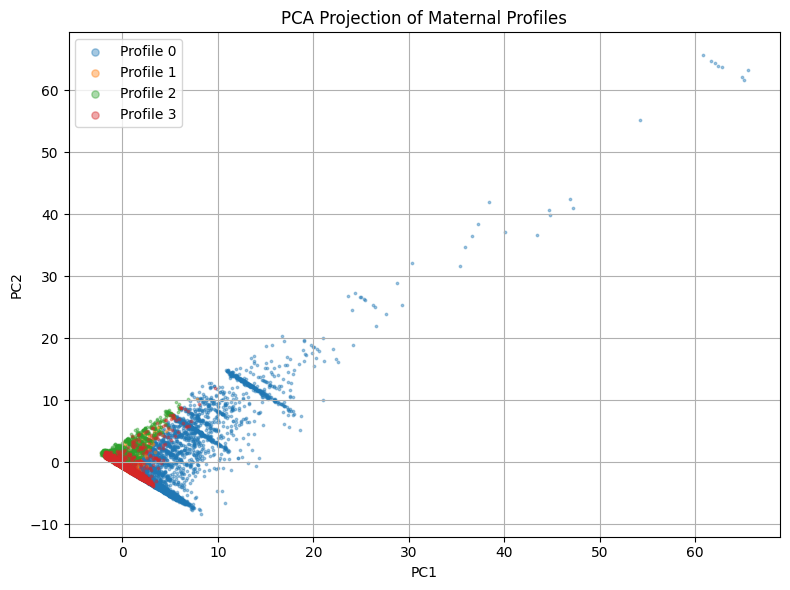

In [27]:
# PCA
plt.figure(figsize=(8,6))

for i in np.unique(cluster_umap):
    mask = cluster_umap == i
    plt.scatter(
        X_pca[umap_idx][mask, 0],
        X_pca[umap_idx][mask, 1],
        s=3,
        alpha=0.4,
        label=f'Profile {i}'
    )

plt.title(f'PCA Projection of Maternal Profiles')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)

plt.legend(markerscale = 3)
plt.tight_layout()
plt.show()

# **Final Dataset to Export**
---
Re-introduce the outcomes

In [28]:
final_clusters_data = pd.concat(
    [official_clustered_data, morbidity_outcomes],
    axis = 1
)
print(final_clusters_data.shape)
display(final_clusters_data.head())

# Export Final Dataset for Modeling

#final_clusters_data.to_csv('/content/drive/MyDrive/Capstone/final_clusters_data.csv', index = False)

(3638436, 44)


,mager,priorlive,priordead,priorterm,rf_cesarn,illb_r,m_ht_in,bmi,wtgain,combgest,...,mracehisp_5.0,mracehisp_6.0,mracehisp_7.0,mracehisp_Unknown,cluster,mm_mtr,mm_plac,mm_rupt,mm_uhyst,mm_aicu
0,30,1.0,0.0,0.0,0.0,30.0,66.0,20.799999,4.0,38.0,...,0,0,0,0,1,0,0,0,0,0
1,28,0.0,0.0,0.0,0.0,36.0,67.0,20.400000,40.0,38.0,...,0,1,0,0,2,0,0,0,0,0
2,41,6.0,0.0,2.0,2.0,84.0,67.0,22.700001,28.0,37.0,...,0,0,0,0,0,0,0,0,0,0
3,29,2.0,0.0,0.0,0.0,49.0,61.0,26.400000,28.0,38.0,...,0,0,0,0,2,0,0,0,0,0
4,28,1.0,0.0,2.0,0.0,17.0,64.0,21.500000,31.0,39.0,...,0,0,0,0,2,0,0,0,0,0


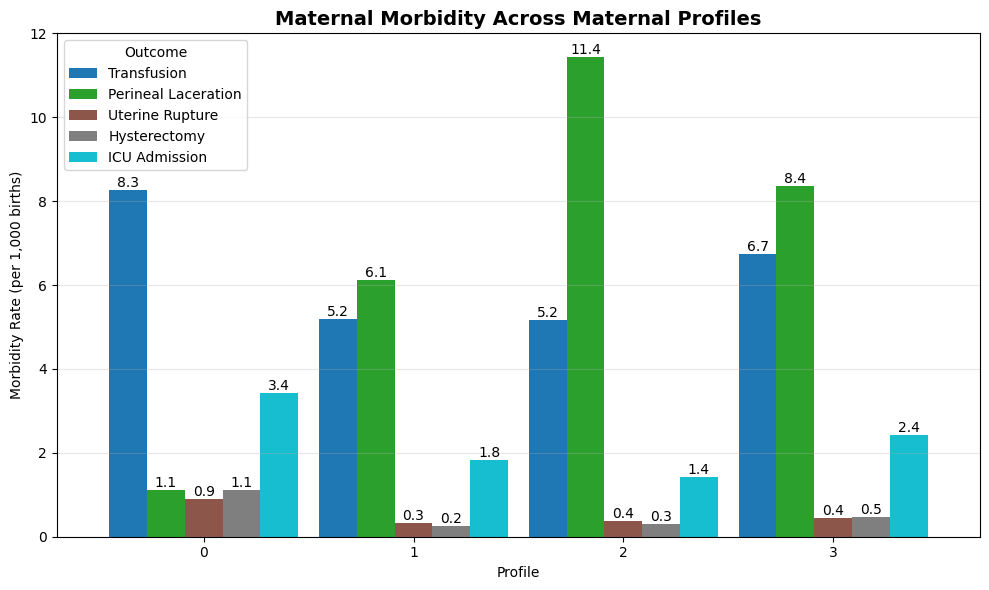

In [29]:
outcomes = ['mm_mtr','mm_plac','mm_rupt','mm_uhyst','mm_aicu']

outcome_rates = final_clusters_data.groupby('cluster')[outcomes].mean() * 1000

# Re-label Outcomes
outcome_map = {
    'mm_mtr': 'Transfusion',
    'mm_plac': 'Perineal Laceration',
    'mm_rupt': 'Uterine Rupture',
    'mm_uhyst': 'Hysterectomy',
    'mm_aicu': 'ICU Admission',
    'any_morb': 'Overall Morbidity'
}

outcome_rates.columns = outcome_rates.columns.map(outcome_map)

ax = outcome_rates.plot(
    kind='bar',
    figsize=(10,6),
    colormap = 'tab10',
    width = 0.9
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=10)

plt.title('Maternal Morbidity Across Maternal Profiles', fontsize=14, fontweight='bold')
plt.ylabel('Morbidity Rate (per 1,000 births)')
plt.xlabel('Profile')
plt.xticks(rotation=0)

plt.legend(title='Outcome', loc='upper left')
plt.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()